# SDSS emission-line galaxies: star formation, composites, and AGN on the BPT diagram

**Archive:** sdss  
**Date:** 2026-07-31  
**Scientific question:** What fraction of a high-S/N low-redshift sample is dominated by star formation or an active nucleus?

This notebook uses public observational data. It separates measurements from
interpretation, carries uncertainties through the main calculation, and records
the exact query or product identifier needed to reproduce the result.

## Analysis contract

A result is accepted only after these checks:

1. record the source, query, retrieval date, and selection cuts;
2. inspect missing values and quality flags before fitting;
3. report sample size and an uncertainty, not only a best value;
4. compare with a published result or accepted physical expectation;
5. state what the data cannot establish.

The saved CSV is the small, queried subset used here—not a replacement for the
upstream archive.

In [1]:
from pathlib import Path
import json
import io
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.style.use(["science", "no-latex"])
COLORS = {"navy": "#071426", "blue": "#4cc9f0", "cyan": "#72efdd",
          "gold": "#ffca58", "orange": "#ff7b54", "pink": "#ef5da8"}
RNG = np.random.default_rng(1999)

## Diagnostic

The BPT diagram compares two pairs of nearby emission lines:
$\log([\mathrm{O III}]/H\beta)$ and
$\log([\mathrm{N II}]/H\alpha)$. Nearby wavelengths reduce sensitivity to
flux calibration and dust. The position reflects the hardness of the ionising
radiation field and separates star-forming galaxies from active galactic nuclei
(AGN), with an intermediate composite region.

In [2]:
import requests

ENDPOINT = "https://skyserver.sdss.org/dr18/SkyServerWS/SearchTools/SqlSearch"
QUERY = '''
SELECT TOP 12000 s.specObjID, s.ra, s.dec, s.z,
 l.h_alpha_flux, l.h_alpha_flux_err,
 l.h_beta_flux, l.h_beta_flux_err,
 l.oiii_5007_flux, l.oiii_5007_flux_err,
 l.nii_6584_flux, l.nii_6584_flux_err
FROM SpecObj AS s
JOIN galSpecLine AS l ON s.specObjID = l.specObjID
WHERE s.class = 'GALAXY' AND s.z BETWEEN 0.01 AND 0.20
AND l.h_alpha_flux > 5*l.h_alpha_flux_err
AND l.h_beta_flux > 5*l.h_beta_flux_err
AND l.oiii_5007_flux > 5*l.oiii_5007_flux_err
AND l.nii_6584_flux > 5*l.nii_6584_flux_err
'''
response = requests.get(ENDPOINT, params={"cmd": QUERY, "format": "csv"}, timeout=180)
response.raise_for_status()
text = response.text.replace("#Table1\n", "", 1)
gal = pd.read_csv(io.StringIO(text))
gal.to_csv("sdss_bpt_query.csv", index=False)
print(f"Retrieved {len(gal):,} galaxies with S/N > 5 in all four lines")
print(f"Redshift range: {gal.z.min():.3f}–{gal.z.max():.3f}; median={gal.z.median():.3f}")

Retrieved 12,000 galaxies with S/N > 5 in all four lines
Redshift range: 0.010–0.200; median=0.075


## Ratios and dividing curves

We use the empirical Kauffmann et al. (2003) curve below which galaxies are
classified as star forming, and the theoretical maximum-starburst Kewley et
al. (2001) curve above which an AGN contribution is required. Objects between
the curves are labelled composite. These labels describe the fibre spectrum,
not necessarily the entire galaxy.

In [3]:
gal["x"] = np.log10(gal.nii_6584_flux / gal.h_alpha_flux)
gal["y"] = np.log10(gal.oiii_5007_flux / gal.h_beta_flux)

def kauffmann(x):
    return 0.61/(x - 0.05) + 1.30

def kewley(x):
    return 0.61/(x - 0.47) + 1.19

sf = (gal.x < 0.05) & (gal.y < kauffmann(gal.x))
agn = (gal.x >= 0.47) | (gal.y >= kewley(gal.x))
gal["class_bpt"] = np.select([sf, agn], ["Star forming", "AGN"], default="Composite")
counts = gal.class_bpt.value_counts()
fractions = (counts / len(gal)).sort_index()
pd.DataFrame({"count": counts, "fraction": counts/len(gal)}).to_csv("bpt_class_fractions.csv")
pd.DataFrame({"count": counts, "fraction": counts/len(gal)}).round(4)

              count  fraction
class_bpt                    
Star forming   8769    0.7308
Composite      2074    0.1728
AGN            1157    0.0964

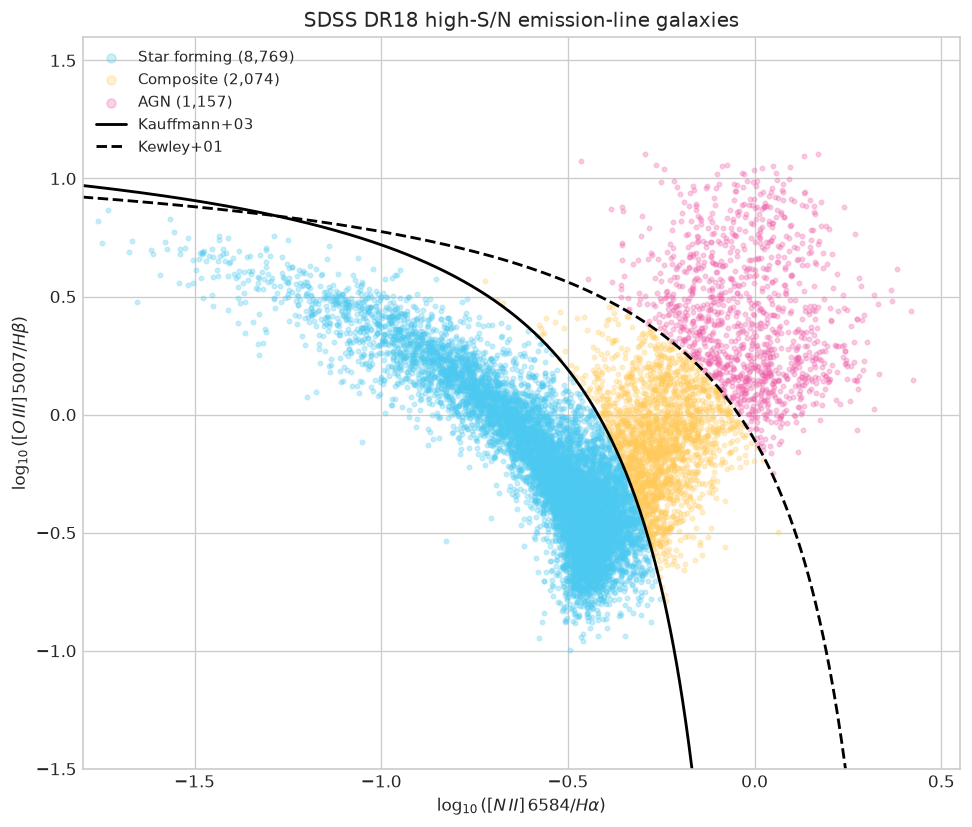

In [4]:
xx1 = np.linspace(-2.0, 0.045, 500)
xx2 = np.linspace(-2.0, 0.465, 500)
palette = {"Star forming": COLORS["blue"], "Composite": COLORS["gold"], "AGN": COLORS["pink"]}
fig, ax = plt.subplots(figsize=(8.2, 7))
for label in ["Star forming", "Composite", "AGN"]:
    part = gal[gal.class_bpt == label]
    ax.scatter(part.x, part.y, s=7, alpha=.28, color=palette[label],
               rasterized=True, label=f"{label} ({len(part):,})")
ax.plot(xx1, kauffmann(xx1), color="black", lw=1.7, label="Kauffmann+03")
ax.plot(xx2, kewley(xx2), color="black", lw=1.7, ls="--", label="Kewley+01")
ax.set(xlim=(-1.8, .55), ylim=(-1.5, 1.6),
       xlabel=r"$\log_{10}([N\,II]\,6584/H\alpha)$",
       ylabel=r"$\log_{10}([O\,III]\,5007/H\beta)$",
       title="SDSS DR18 high-S/N emission-line galaxies")
ax.legend(markerscale=2, fontsize=9)
fig.tight_layout()
fig.savefig("sdss_bpt_diagram.png", dpi=190)
plt.show()

## Fraction uncertainty

The sample is not volume-complete, so sampling uncertainty is not the dominant
scientific limitation. Still, Wilson binomial intervals quantify finite-count
uncertainty for the observed sample. The much larger systematic question is how
the four-line S/N cut favours strong emission-line galaxies.

In [5]:
from statsmodels.stats.proportion import proportion_confint

interval_rows = []
for label, n in counts.items():
    lo, hi = proportion_confint(n, len(gal), alpha=0.05, method="wilson")
    interval_rows.append([label, n/len(gal), lo, hi])
intervals = pd.DataFrame(interval_rows, columns=["class", "fraction", "ci95_low", "ci95_high"])
intervals.round(4)

          class  fraction  ci95_low  ci95_high
0  Star forming    0.7308    0.7227     0.7386
1     Composite    0.1728    0.1662     0.1797
2           AGN    0.0964    0.0913     0.1018

## Balmer decrement as a dust indicator

Unobscured case-B recombination predicts $H\alpha/H\beta\approx2.86$.
Larger ratios are commonly interpreted as dust reddening. Using a standard
Milky-Way attenuation curve gives an indicative colour excess. Negative values
are retained as noise/model scatter rather than silently clipped.

In [6]:
k_hbeta, k_halpha = 3.61, 2.53
gal["balmer_decrement"] = gal.h_alpha_flux / gal.h_beta_flux
gal["ebv"] = 2.5/(k_hbeta-k_halpha) * np.log10(gal.balmer_decrement/2.86)
dust = gal.groupby("class_bpt").agg(
    n=("ebv", "size"),
    median_ebv=("ebv", "median"),
    median_balmer=("balmer_decrement", "median"),
    median_z=("z", "median")
)
dust.round(3)

                 n  median_ebv  median_balmer  median_z
class_bpt                                              
AGN           1157       0.344          4.025     0.086
Composite     2074       0.446          4.457     0.085
Star forming  8769       0.299          3.851     0.072

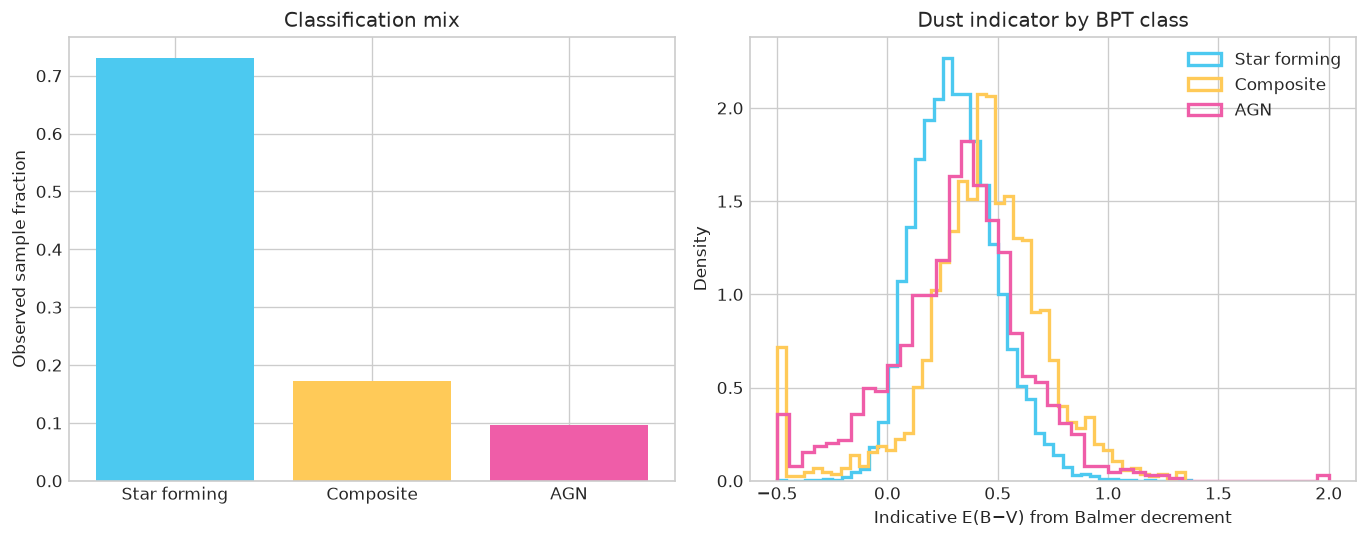

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
ordered = ["Star forming", "Composite", "AGN"]
axes[0].bar(ordered, [fractions[x] for x in ordered],
            color=[palette[x] for x in ordered])
axes[0].set(ylabel="Observed sample fraction", title="Classification mix")
for i, label in enumerate(ordered):
    vals = gal.loc[gal.class_bpt == label, "ebv"].clip(-.5, 2)
    axes[1].hist(vals, bins=45, histtype="step", density=True, lw=2,
                 color=palette[label], label=label)
axes[1].set(xlabel="Indicative E(B−V) from Balmer decrement",
            ylabel="Density", title="Dust indicator by BPT class")
axes[1].legend()
fig.tight_layout()
fig.savefig("sdss_bpt_summary.png", dpi=180)
plt.show()

## What is established—and what is not

This notebook establishes the classification mix *within the selected
high-S/N fibre spectra*. It does not measure the cosmic AGN fraction: that
requires a defined parent sample, completeness corrections, aperture analysis,
and treatment of non-detections. Borderline sources also have classification
uncertainty because line-flux errors can move them across a curve.

In [8]:
result = {
    "id": "2026-07-31-sdss-bpt-galaxy-classification",
    "title": "SDSS BPT galaxy classification",
    "archive": "SDSS DR18",
    "date": "2026-07-31",
    "question": "How are high-S/N low-redshift fibre spectra divided among ionisation classes?",
    "sample_size": int(len(gal)),
    "results": [
        f"{100*fractions['Star forming']:.1f}% star forming",
        f"{100*fractions['Composite']:.1f}% composite",
        f"{100*fractions['AGN']:.1f}% AGN within the four-line-selected sample"
    ],
    "validation": "Class boundaries reproduce the published Kauffmann (2003) and Kewley (2001) demarcations.",
    "notebook": "sdss/2026-07-31-sdss-bpt-galaxy-classification/notebook.ipynb",
    "hero": "sdss/2026-07-31-sdss-bpt-galaxy-classification/sdss_bpt_diagram.png",
    "tags": ["galaxies", "spectroscopy", "AGN", "emission lines"]
}
Path("result.json").write_text(json.dumps(result, indent=2))
print("\n".join("• " + x for x in result["results"]))

• 73.1% star forming
• 17.3% composite
• 9.6% AGN within the four-line-selected sample


## References and data acknowledgement


- SDSS DR18 SkyServer `SpecObj` and `galSpecLine` tables:
  https://skyserver.sdss.org/dr18/
- Kewley et al. (2001), *Theoretical Modeling of Starburst Galaxies*:
  https://doi.org/10.1086/321545
- Kauffmann et al. (2003), *The host galaxies of active galactic nuclei*:
  https://doi.org/10.1046/j.1365-2966.2003.07154.x
- SDSS acknowledgement: https://www.sdss.org/collaboration/citing-sdss/


The numerical results above are conditional on the documented cuts. Re-running
later can change catalog-based values as archives are revised.